<a href="https://colab.research.google.com/github/adimika04-collab/Topik-Statistik-1/blob/main/Topik_Statistik_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model AR(1) Teoritis:
Y_t = 1 + 0.2 Y_(t-1) + e_t
dengan e_t ~ N(0, 1)



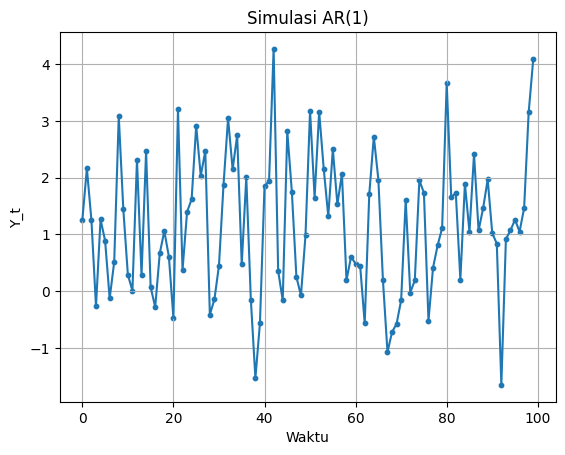

<Figure size 640x480 with 0 Axes>

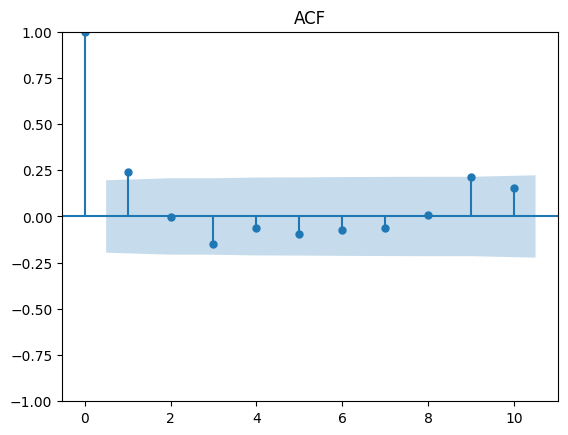

<Figure size 640x480 with 0 Axes>

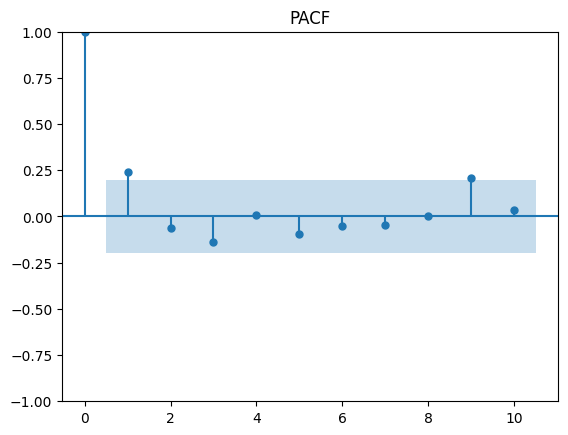

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  100
Model:                     AutoReg(1)   Log Likelihood                -157.743
Method:               Conditional MLE   S.D. of innovations              1.191
Date:                Wed, 15 Apr 2026   AIC                            321.485
Time:                        01:16:50   BIC                            329.271
Sample:                             1   HQIC                           324.635
                                  100                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8797      0.166      5.315      0.000       0.555       1.204
y.L1           0.2532      0.100      2.523      0.012       0.057       0.450
                                    Roots           

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

# =========================
# A. Parameter
# =========================
n = 100
phi = 0.2
mu = 1
sigma = 1.0

# =========================
# B. Tampilkan Model Teoritis
# =========================
print("Model AR(1) Teoritis:")
print(f"Y_t = {mu} + {phi} Y_(t-1) + e_t")
print("dengan e_t ~ N(0, 1)\n")

# =========================
# C. Simulasi AR(1)
# =========================
def simulate_ar1(phi, mu, n, sigma=1.0):
    Y = np.zeros(n)
    Y[0] = mu / (1 - phi)
    e = np.random.normal(0, sigma, n)

    for t in range(1, n):
        Y[t] = mu + phi * Y[t-1] + e[t]

    return Y

Y = simulate_ar1(phi, mu, n, sigma)

# =========================
# D. Plot Time Series
# =========================
plt.figure()
plt.plot(Y)
plt.scatter(range(n), Y, s=10)
plt.title("Simulasi AR(1)")
plt.xlabel("Waktu")
plt.ylabel("Y_t")
plt.grid()
plt.show()

# =========================
# E. ACF
# =========================
plt.figure()
plot_acf(Y, lags=10)
plt.title("ACF")
plt.show()

# =========================
# F. PACF
# =========================
plt.figure()
plot_pacf(Y, lags=10)
plt.title("PACF")
plt.show()

# =========================
# G. Estimasi Model AR(1)
# =========================
model = AutoReg(Y, lags=1)
model_fit = model.fit()

print(model_fit.summary())

# =========================
# H. Tampilkan Model Hasil Estimasi
# =========================
const = model_fit.params[0]
phi_est = model_fit.params[1]

print("\nModel AR(1) Hasil Estimasi:")
print(f"Y_t = {const:.4f} + {phi_est:.4f} Y_(t-1) + e_t")